# Longitudinal analysis of memory B cells in preRA cohort

- Related to Fig 3
- run subclustering for effector B cells


In [4]:
# load lib
import hisepy as hp
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as scs
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation

In [20]:
# set plotting parameter
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42

In [6]:
# define some color patterns for plotting
nejm_color = [
    "#BC3C29FF",
    "#0072B5FF",
    "#E18727FF",
    "#20854EFF",
    "#7876B1FF",
    "#6F99ADFF",
    "#FFDC91FF",
    "#EE4C97FF",
]
jama_color = [
    "#374E55FF",
    "#DF8F44FF",
    "#00A1D5FF",
    "#B24745FF",
    "#79AF97FF",
    "#6A6599FF",
    "#80796BFF",
]

In [16]:
# define working path
data_path = "/home/workspace/data/ra_longitudinal/scrna/certPro/"
fig_path = "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/figures/"
meta_path = "/home/workspace/github/ra-longitudinal/metadata/"
output_path = (
    "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/Bmem_results/"
)
# os.mkdir(output_path)
# define a project name
proj_name = "ALTRA_scRNA_Bmem_certPro_"
# sc.set_figure_params(fig_path)
sc.settings.figdir = fig_path
sc.settings.autosave = False
sc.set_figure_params(vector_friendly=True, dpi_save=100)

In [17]:
def save_plot(fig, ax, save):
    """
    Save a matplotlib figure to a file.

    Parameters:
    - fig: The matplotlib figure object to be saved.
    - ax: The matplotlib axes object associated with the figure.
    - save: The file path to save the figure to.

    Raises:
    - ValueError: If any of the input parameters are None.

    Returns:
    - None
    """
    if save is not None:
        if ax is not None:
            if fig is not None:
                fig.savefig(save, bbox_inches="tight")
            else:
                raise ValueError("fig is None, cannot save figure.")
        else:
            raise ValueError("ax is None, cannot save figure.")


def filter_limits(df, sign_limit=None, lFCs_limit=None):
    """
    Filter a DataFrame based on sign and log fold change limits.

    Parameters:
    df (DataFrame): The input DataFrame to be filtered.
    sign_limit (float, optional): The limit for p-values. Default is None.
    lFCs_limit (float, optional): The limit for log fold changes. Default is None.

    Returns:
    DataFrame: The filtered DataFrame based on the specified limits.
    """

    # Define limits if not defined
    if sign_limit is None:
        sign_limit = np.inf
    if lFCs_limit is None:
        lFCs_limit = np.inf

    # Filter by absolute value limits
    msk_sign = df["pvals"] < np.abs(sign_limit)
    msk_lFCs = np.abs(df["logFCs"]) < np.abs(lFCs_limit)
    df = df.loc[msk_sign & msk_lFCs]

    return df


def plot_volcano_df(
    data,
    x,
    y,
    top=5,
    genes=None,
    sign_thr=0.05,
    lFCs_thr=0.5,
    sign_limit=None,
    lFCs_limit=None,
    color_pos="#D62728",
    color_neg="#1F77B4",
    color_null="gray",
    figsize=(7, 5),
    dpi=100,
    ax=None,
    return_fig=False,
    save=None,
):
    """
    Plot logFC and p-values from a long formated data-frame.

    Parameters
    ----------
    data : pd.DataFrame
        Results of DEA in long format.
    x : str
        Column name of data storing the logFCs.
    y : str
        Columns name of data storing the p-values.
    top : int
        Number of top differentially expressed features to show.
    sign_thr : float
        Significance threshold for p-values.
    lFCs_thr : float
        Significance threshold for logFCs.
    sign_limit : float
        Limit of p-values to plot in -log10.
    lFCs_limit : float
        Limit of logFCs to plot in absolute value.
    color_pos: str
        Color to plot significant positive genes.
    color_neg: str
        Color to plot significant negative genes.
    color_null: str
        Color to plot rest of the genes.
    figsize : tuple
        Figure size.
    dpi : int
        DPI resolution of figure.
    ax : Axes, None
        A matplotlib axes object. If None returns new figure.
    return_fig : bool
        Whether to return a Figure object or not.
    save : str, None
        Path to where to save the plot. Infer the filetype if ending on {``.pdf``, ``.png``, ``.svg``}.

    Returns
    -------
    fig : Figure, None
        If return_fig, returns Figure object.
    """
    import numpy as np
    from adjustText import adjust_text

    # # Load plotting packages
    # plt = check_if_matplotlib()
    # at = check_if_adjustText()
    # Transform sign_thr
    sign_thr = -np.log10(sign_thr)

    # Extract df
    df = data.copy()
    df["logFCs"] = df[x]
    df["pvals"] = -np.log10(df[y])

    # Filter by limits
    df = filter_limits(df, sign_limit=sign_limit, lFCs_limit=lFCs_limit)

    # Define color by up or down regulation and significance
    df["weight"] = color_null
    up_msk = (df["logFCs"] >= lFCs_thr) & (df["pvals"] >= sign_thr)
    dw_msk = (df["logFCs"] <= -lFCs_thr) & (df["pvals"] >= sign_thr)
    df.loc[up_msk, "weight"] = color_pos
    df.loc[dw_msk, "weight"] = color_neg

    # Plot
    fig = None
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    df.plot.scatter(x="logFCs", y="pvals", c="weight", sharex=False, ax=ax)
    ax.set_axisbelow(True)

    # Draw sign lines
    ax.axhline(y=sign_thr, linestyle="--", color="black")
    ax.axvline(x=lFCs_thr, linestyle="--", color="black")
    ax.axvline(x=-lFCs_thr, linestyle="--", color="black")

    if genes is None:
        # Plot top sign features
        signs = df[up_msk | dw_msk].sort_values("pvals", ascending=False)
        signs = signs.iloc[:top]
    else:
        signs = df[up_msk | dw_msk].sort_values("pvals", ascending=False)
        signs = signs.loc[signs.index.isin(genes)]
    # Add labels
    ax.set_ylabel("-log10(p.adj)")
    ax.set_xlabel("Log2 fold change")
    texts = []
    for x, y, s in zip(signs["logFCs"], signs["pvals"], signs.index):
        texts.append(ax.text(x, y, s))
    if len(texts) > 0:
        adjust_text(texts, arrowprops=dict(arrowstyle="-", color="black"), ax=ax)

    save_plot(fig, ax, save)

    if return_fig:
        return fig


# define helper function
def get_marker_expression_stats(adata, markers, cluster_col):
    """
    Calculate mean expression and percent expressing cells for given markers per cluster.

    Parameters
    ----------
    adata : AnnData
        AnnData object with expression data.
    markers : list of str
        List of marker gene names.
    cluster_col : str
        Column in adata.obs to group by (e.g., cluster label).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: cluster_col, gene, mean_expression, percent_expressing
    """
    # Check if cluster_col exists in adata.obs
    if cluster_col not in adata.obs.columns:
        raise ValueError(
            f"'{cluster_col}' not found in adata.obs columns: {list(adata.obs.columns)}"
        )

    # Extract marker expression and cluster info into a DataFrame
    df = sc.get.obs_df(adata, keys=markers + [cluster_col])

    # Define percent expressing function
    def percent_expressing(x):
        return np.mean(x > 0) * 100

    # Aggregate: get mean and percent expressing for each marker per cluster
    agg_df = (
        df.groupby(cluster_col)[markers].agg([percent_expressing, "mean"]).reset_index()
    )

    # If cluster_col is not a column, reset index to make it a column
    if cluster_col not in agg_df.columns:
        agg_df = agg_df.reset_index()

    # Reshape to tidy format:
    # - set cluster_col as index
    # - melt to long format
    # - rename columns for clarity
    # - pivot so each row is cluster/gene, columns are metrics
    result = (
        agg_df.set_index(cluster_col)
        .melt(value_name="value", ignore_index=False)
        .rename(columns={"variable_0": "gene", "variable_1": "metric"})
        .reset_index()
        .pivot(index=[cluster_col, "gene"], columns="metric", values="value")
        .reset_index()
    )

    # Rename columns for clarity
    result = result.rename(
        columns={"mean": "mean_expression", "percent_expressing": "percent_expressing"}
    )

    # Remove index name if present
    result.index.name = None

    return result

In [9]:
# set fig size
plt.rcParams["figure.figsize"] = [10, 8]

# load Mem B cells data and rerun the umap and clusters


In [10]:
hp.cache_files(["89859cec-8d36-47fd-a165-f0f34ae90284"])

['/home/workspace/input/569004694/UCSDCU_Y4/89859cec-8d36-47fd-a165-f0f34ae90284/ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad']

In [12]:
# load filters data
Bmem_adata = sc.read_h5ad(
    "/home/workspace/input/569004694/UCSDCU_Y4/89859cec-8d36-47fd-a165-f0f34ae90284/ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad",
    backed="r",
)

In [ ]:
pred_scores = Bmem_adata.obs[
    ["AIFI_L1", "AIFI_L1_score", "AIFI_L2", "AIFI_L2_score", "AIFI_L3", "AIFI_L3_score"]
]

In [ ]:
sns.boxplot(
    data=pred_scores, x="AIFI_L3", y="AIFI_L3_score", hue="AIFI_L3", whis=(0, 100)
)

In [ ]:
def get_ig_genes(adata):
    igl_genes = [gene for gene in adata.var_names if gene.startswith("IGL")]
    igk_genes = [gene for gene in adata.var_names if gene.startswith("IGK")]
    ighc_genes = [gene for gene in adata.var_names if gene.startswith("IGH")]
    exl_genes = igl_genes + igk_genes + ighc_genes
    return exl_genes

In [ ]:
# remove ig genes from clustering
ig_genes = get_ig_genes(Bmem_adata)
Bmem_adata.var.loc[Bmem_adata.var.index.isin(ig_genes), "highly_variable"] = False

In [ ]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
sc.pp.pca(Bmem_adata, svd_solver="arpack", use_highly_variable=True)

In [ ]:
# plot the principle component variance explained
sc.pl.pca_variance_ratio(Bmem_adata, log=True)

In [ ]:
# rerun neibor and ummap
sc.pp.neighbors(Bmem_adata, n_pcs=15, use_rep="X_pca")
sc.tl.umap(Bmem_adata)
Bmem_adata.obsm["X_orignial_umap"] = Bmem_adata.obsm["X_umap"].copy()

In [ ]:
Bmem_adata

In [ ]:
# run clusters
sc.tl.leiden(Bmem_adata, key_added="leiden_0_8", resolution=0.8)
sc.tl.leiden(Bmem_adata, key_added="leiden_1", resolution=1)
sc.tl.leiden(Bmem_adata, key_added="leiden_1_2", resolution=1.2)

In [ ]:
Bmem_adata.obs["AIFI_L3_new"].unique()

In [ ]:
# run cluster in the cd27- effector cell only
sc.tl.leiden(
    Bmem_adata,
    key_added="swit_effect_leiden",
    resolution=0.05,
    restrict_to=("AIFI_L3_new", ["CD27- effector B cell"]),
)

In [ ]:
# Bmem_adata.obs['swit_effect_leiden'].value_counts()

In [ ]:
sc.pl.umap(
    Bmem_adata,
    legend_loc="on data",
    color=["AIFI_L2", "AIFI_L3_new", "leiden_0_8", "leiden_1", "leiden_1_2", "status"],
    ncols=3,
    frameon=False,
    save=proj_name + "leiden_umap.png",
)

### plot Fig 3A


In [21]:
Bmem_adata

AnnData object with n_obs × n_vars = 58295 × 33538 backed at '/home/workspace/input/569004694/UCSDCU_Y4/89859cec-8d36-47fd-a165-f0f34ae90284/ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad'
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_5

In [14]:
# define the B mem colors
pop_colors = {
    "Activated memory B cell": "#805D93",
    "CD27+ effector B cell": "#CF7C63",
    "CD27- effector B cell": "#861D31",
    "CD95 memory B cell": "#263FA6",
    "Core memory B cell": "#399390",
    "Early memory B cell": "#C4E2E1",
    "Type 2 polarized memory B cell": "#849324",
}

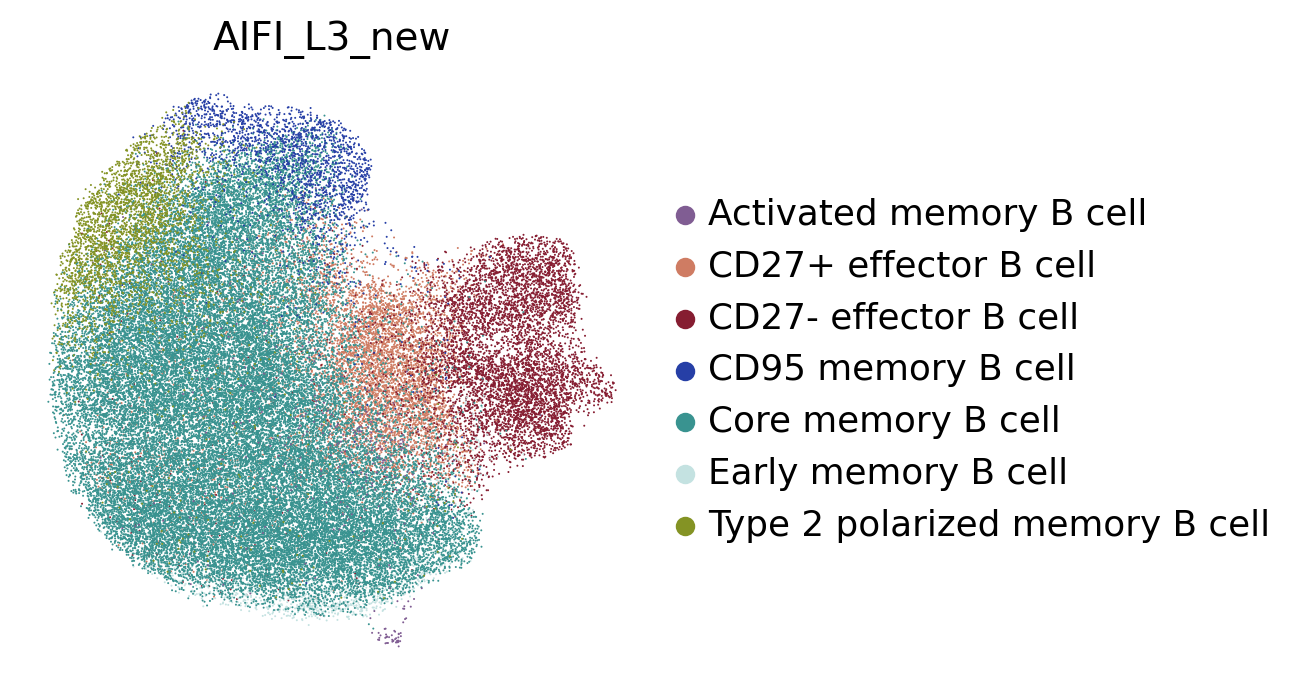

In [19]:
with plt.rc_context({"figure.figsize": (4, 4), "figure.dpi": (100)}):
    sc.pl.umap(
        Bmem_adata,  # legend_loc='on data',
        color=["AIFI_L3_new"],
        palette=pop_colors,
        title=None,
        frameon=False,
        save=proj_name + "AIFI_L3_new_umap.pdf",
    )

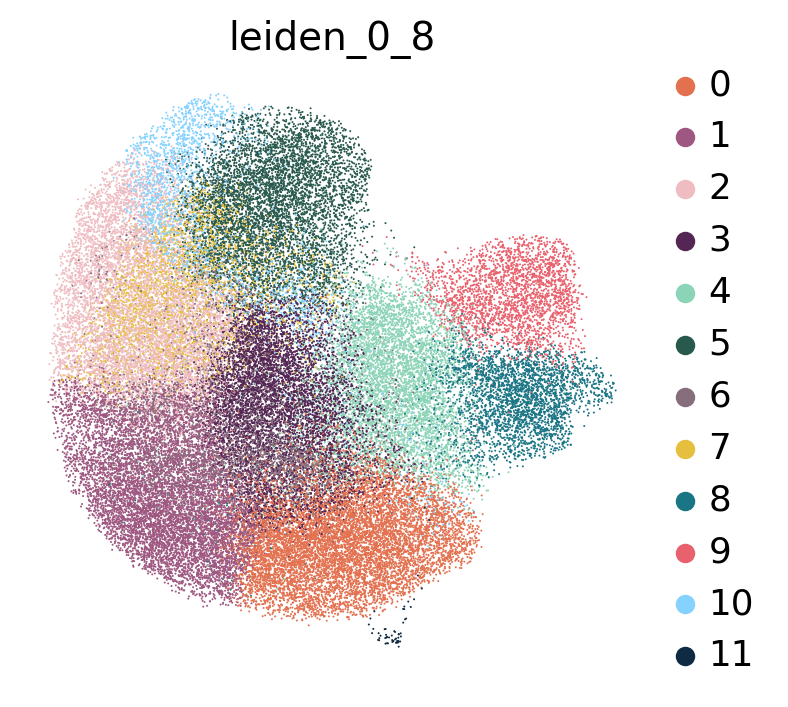

In [24]:
# plot the cluters umap
cluster_colors = [
    "#E3714F",
    "#9E5780",
    "#efbdc1",
    "#542654",
    "#8cd4b7",
    "#28594d",
    "#876e7d",
    "#e7bf3e",
    "#1a7585",
    "#e9616d",
    "#85d2ff",
    "#0f2a43",
]
with plt.rc_context({"figure.figsize": (4, 4), "figure.dpi": (100)}):
    sc.pl.umap(
        Bmem_adata,  # legend_loc='on data',
        color=["leiden_0_8"],
        palette=cluster_colors,
        title=None,
        frameon=False,
        save=proj_name + "leiden_0_8_umap.pdf",
    )

In [ ]:
# test for top genes that seperate the cells
cluster_name = "leiden_0_8"
sc.tl.rank_genes_groups(
    Bmem_adata, groupby=cluster_name, method="wilcoxon", key_added="leiden_0_8_wilcoxon"
)

In [ ]:
# output the deg list
leiden_deg = sc.get.rank_genes_groups_df(
    Bmem_adata, key=cluster_name + "_wilcoxon", pval_cutoff=None, group=None
).rename({"group": cluster_name}, axis="columns")
leiden_deg["direction"] = np.where(leiden_deg["logfoldchanges"] > 0, "up", "down")
leiden_deg = leiden_deg.reindex(
    leiden_deg["scores"].abs().sort_values(ascending=False).index
)
leiden_deg.to_csv(output_path + proj_name + cluster_name + "_wilcoxon_degs.csv")

In [ ]:
leiden_deg.loc[leiden_deg["pvals_adj"] < 0.01].to_csv(
    output_path + proj_name + cluster_name + "_wilcoxon_sig_degs.csv"
)

In [ ]:
# plot top degs
sc.tl.dendrogram(Bmem_adata, groupby=cluster_name)
sc.pl.rank_genes_groups_dotplot(
    Bmem_adata,
    groupby=cluster_name,
    standard_scale="var",
    n_genes=10,
    key=cluster_name + "_wilcoxon",
    save="_" + proj_name + cluster_name + "_wilcoxon_top_genes_dotplot_scale.png",
)

## plot Fig S6B

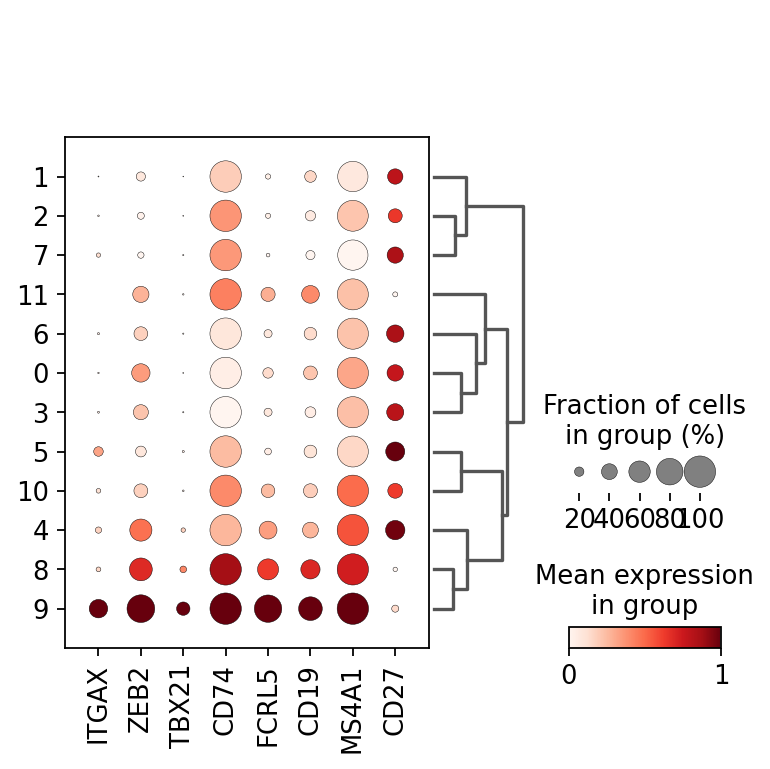

In [22]:
# plot marker genes from the annoatation table
marker_genes = ["ITGAX", "ZEB2", "TBX21", "CD74", "FCRL5", "CD19", "MS4A1", "CD27"]
cluster_name = "leiden_0_8"
sc.pl.dotplot(
    Bmem_adata,
    marker_genes,
    groupby=cluster_name,
    standard_scale="var",
    dendrogram=True,
    swap_axes=False,
    save="_" + proj_name + "_effector_" + cluster_name + "_marker_genes_dotplot.pdf",
)

# isolate effector clusters from Mem B cells

In [18]:
# isolate effector clusters from Mem B cells
Bmem_adata_eff = Bmem_adata[Bmem_adata.obs["leiden_0_8"].isin(["8", "9"])].copy()
Bmem_adata_eff

AnnData object with n_obs × n_vars = 5623 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'Stat

### plot Fig 3B right panel

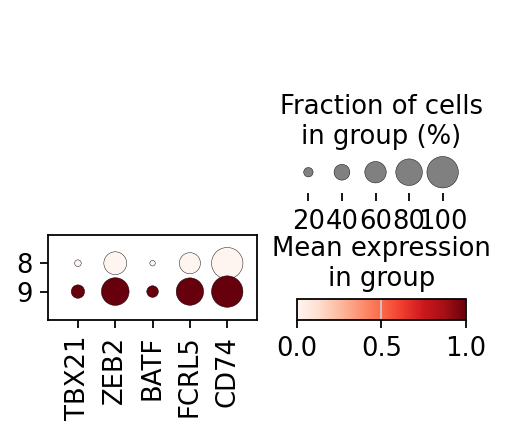

In [23]:
# plot marker genes from the annoatation table
marker_genes = ["TBX21", "ZEB2", "BATF", "FCRL5", "CD74"]
cluster_name = "leiden_0_8"
sc.pl.dotplot(
    Bmem_adata_eff,
    marker_genes,
    groupby=cluster_name,
    standard_scale="var",
    dendrogram=True,
    swap_axes=False,
    save="_"
    + proj_name
    + "_effector_"
    + cluster_name
    + "_marker_genes_trimed_dotplot_unscale.pdf",
)

### plot Fig S6C
- dotplot in effector cells only


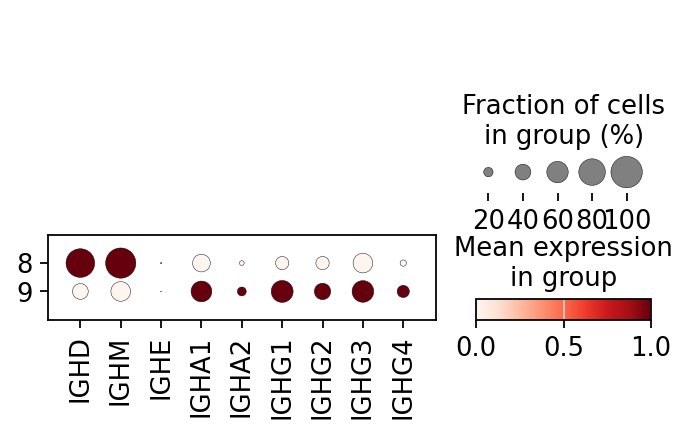

In [20]:
# plot marker genes from the annoatation table
cluster_name = "leiden_0_8"
ig_genes = [
    "IGHD",
    "IGHM",
    "IGHE",
    "IGHA1",
    "IGHA2",
    "IGHG1",
    "IGHG2",
    "IGHG3",
    "IGHG4",
]
sc.pl.dotplot(
    Bmem_adata_eff,
    ig_genes,
    groupby=cluster_name,
    standard_scale="var",
    dendrogram=True,
    swap_axes=False,
    save="_" + proj_name + "_effector_" + cluster_name + "_ig_genes_dotplot_scale.pdf",
)

In [ ]:
# save data
Bmem_adata.write_h5ad(data_path + "ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad")

### plot Fig3B left panel
- compare degs from cluster 9 and cluster 8

In [25]:
# test for top genes that seperate the cells
cluster_name = "leiden_0_8"
sc.tl.rank_genes_groups(
    Bmem_adata_eff,
    groupby=cluster_name,
    groups=["9"],
    reference="8",
    method="wilcoxon",
    key_added="leiden_1_wilcoxon_c9vsc8",
)

In [26]:
Bmem_adata_eff

AnnData object with n_obs × n_vars = 5623 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'Stat

In [27]:
c9vsc8_degs = sc.get.rank_genes_groups_df(
    Bmem_adata_eff, key="leiden_1_wilcoxon_c9vsc8", pval_cutoff=0.05, group=None
)
c9vsc8_degs = c9vsc8_degs.reindex(
    c9vsc8_degs["pvals_adj"].sort_values(ascending=True).index
)
c9vsc8_degs.to_csv(
    output_path + proj_name + cluster_name + "c9vsc8_wilcoxon_sig_degs.csv"
)

In [28]:
cluster_name = "leiden_0_8"
c9vsc8_degs = pd.read_csv(
    output_path + proj_name + cluster_name + "c9vsc8_wilcoxon_sig_degs.csv"
)
c9vsc8_degs = c9vsc8_degs.set_index("names")
c9vsc8_degs

,Unnamed: 0,scores,logfoldchanges,pvals,pvals_adj
names,,,,,
CIB1,0,37.971730,1.651196,0.000000e+00,0.000000e+00
IGHD,2059,-39.522972,-2.802448,0.000000e+00,0.000000e+00
IGHM,2060,-41.827290,-3.113596,0.000000e+00,0.000000e+00
TMSB4X,1,37.224125,0.644174,2.778765e-303,2.329855e-299
CD79B,2058,-34.441525,-1.169883,6.031199e-260,4.045487e-256
...,...,...,...,...,...
OXR1,1749,2.964803,0.258902,3.028765e-03,4.938198e-02
CCDC124,1750,2.964613,0.314712,3.030635e-03,4.938845e-02
EXOC4,1752,2.961775,0.448602,3.058716e-03,4.979768e-02


/home/workspace/environment/scanpy/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


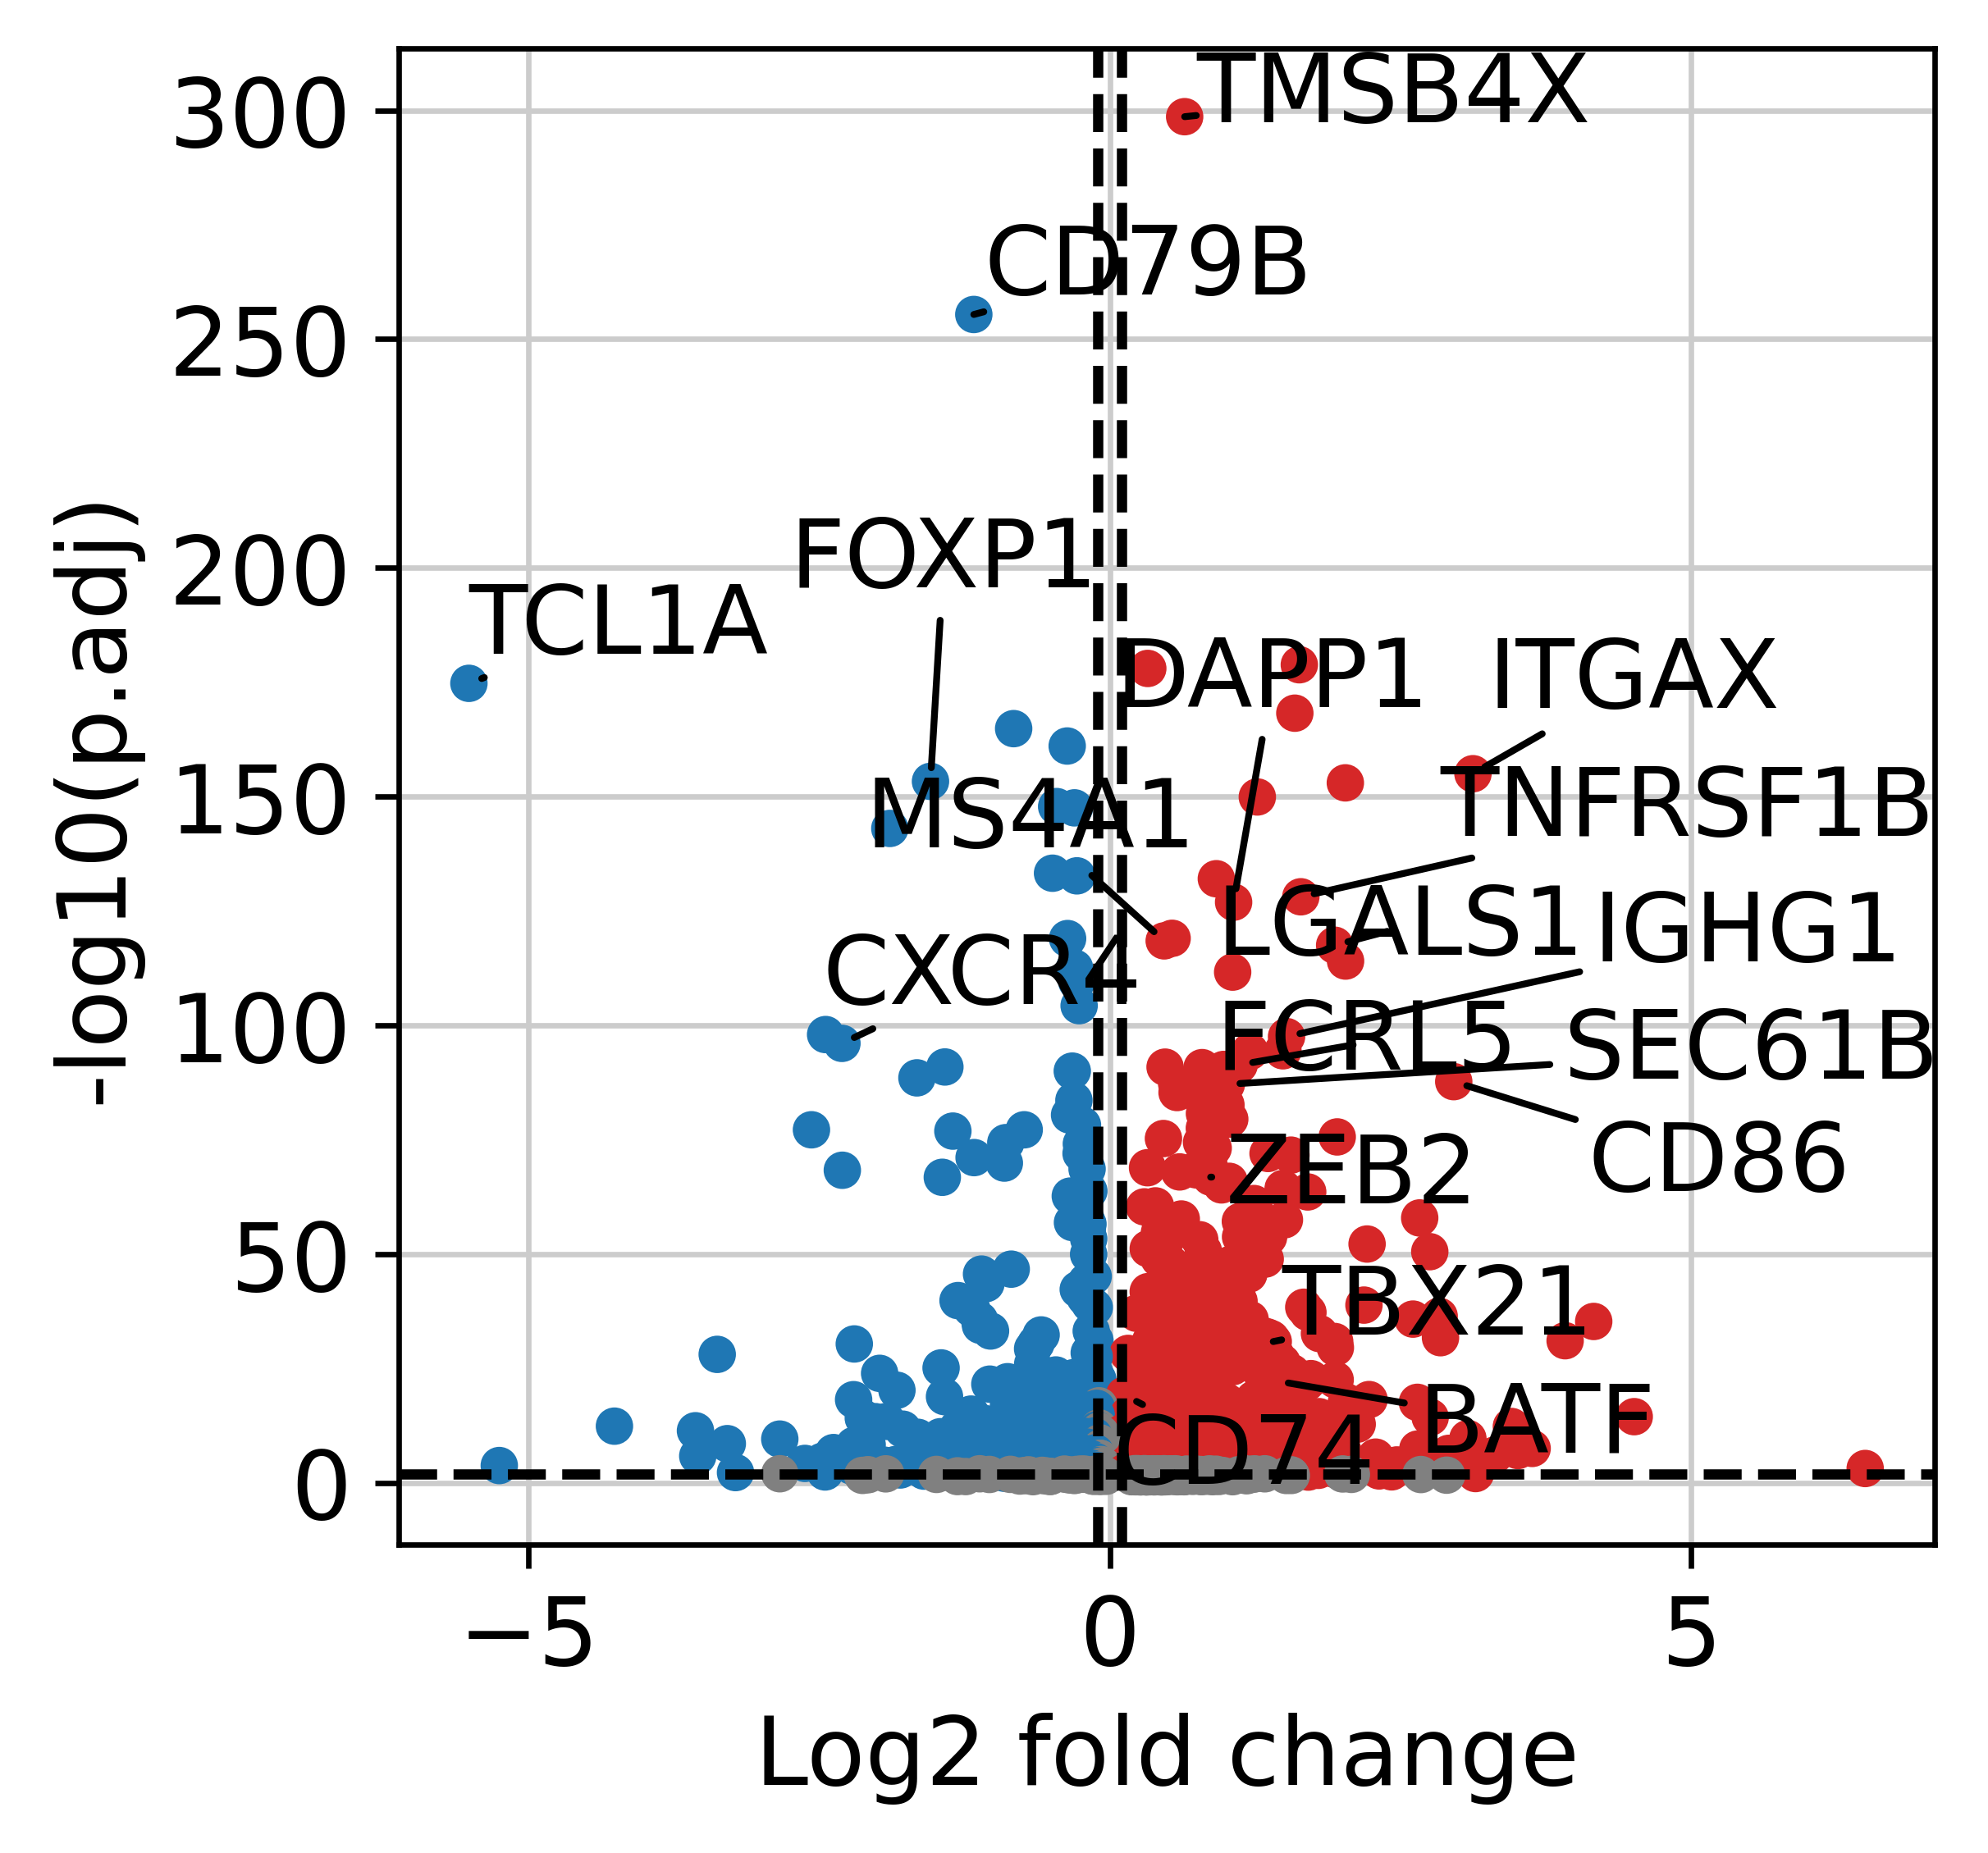

In [30]:
genes_plot = [
    "CD79B",
    "DAPP1",
    "ITGAX",
    "BATF",
    "FCRL5",
    "CD86",
    "SEC61B",
    "CD74",
    "MS4A1",
    "TBX21",
    "ZEB2",
    "CXCR4",
    "TCL1A",
    "TNFRSF1B",
    "FOXP1",
    "LGALS1",
    "IGHG1",
    "TMSB4X",
]
plot_volcano_df(
    c9vsc8_degs,
    genes=genes_plot,
    x="logfoldchanges",
    y="pvals_adj",
    # top=40,
    lFCs_thr=0.1,
    sign_thr=0.01,
    figsize=(4, 4),
    dpi=300,
    save=fig_path + proj_name + cluster_name + "_c9vsc8_degs_top40_valcano.pdf",
)

## calculate the frequency of each clusters


In [ ]:
# add the new labels to label the two clusters of cd27- effector cells and use the other subset
Bmem_adata.obs["leiden_0_8_anno"] = Bmem_adata.obs["AIFI_L3_new"].astype("str").copy()
Bmem_adata.obs.loc[
    (Bmem_adata.obs["AIFI_L3_new"] == "CD27- effector B cell")
    & (Bmem_adata.obs["leiden_0_8"] == "8"),
    "leiden_0_8_anno",
] = "CD27- effector B cell_C8"
Bmem_adata.obs.loc[
    (Bmem_adata.obs["AIFI_L3_new"] == "CD27- effector B cell")
    & (Bmem_adata.obs["leiden_0_8"] == "9"),
    "leiden_0_8_anno",
] = "CD27- effector B cell_C9"

Bmem_adata.obs["leiden_0_8_anno"] = Bmem_adata.obs["leiden_0_8_anno"].astype("category")

In [ ]:
Bmem_adata.obs["leiden_0_8_anno"].value_counts()

In [ ]:
# save the entire metadata
# Bmem_adata.obs.to_csv(output_path + proj_name + 'obs_metada.tsv', sep="\t")

In [ ]:
# get monocytes subset freuqency
cluster_name = "leiden_0_8"
Bmem_freq = sct.tools.relative_frequency_per_cluster(
    Bmem_adata, group_by="sample.sampleKitGuid", xlabel=cluster_name
)
Bmem_freq = (
    Bmem_freq.set_index(["sample.sampleKitGuid"])
    .melt(ignore_index=False, var_name="cluster", value_name="bmem_frequency")
    .reset_index()
)

# add cell counts
cell_counts = (
    Bmem_adata.obs.groupby(["sample.sampleKitGuid", cluster_name])
    .size()
    .reset_index(name="counts")
)
total_counts = (
    Bmem_adata.obs.groupby(["sample.sampleKitGuid"])
    .size()
    .reset_index(name="bmem_counts")
)
cell_counts = cell_counts.merge(
    total_counts, how="left", on=["sample.sampleKitGuid"]
).rename({cluster_name: "cell_type"}, axis=1)
# add metadata to it
Bmem_freq = (
    Bmem_freq.merge(
        Bmem_adata.obs.loc[
            :,
            [
                "sample.sampleKitGuid",
                "subject.subjectGuid",
                "subject.biologicalSex",
                "days_to_conversion",
                "status",
                "file.batchID",
                "Status_Long",
                "age_conv",
                "bmi_conv",
                "BMI",
                "anti_ccp3_finalCombined",
                "Status_Xsec",
                "total_b_counts",
            ],
        ].drop_duplicates(),
        how="left",
        on="sample.sampleKitGuid",
    )
    .rename({"cluster": "cell_type"}, axis=1)
    .merge(cell_counts, how="left", on=["sample.sampleKitGuid", "cell_type"])
)
Bmem_freq

In [ ]:
# save the frequency table
Bmem_freq.to_csv(
    output_path + proj_name + "B_mem_effector_" + cluster_name + "anno_freq.csv"
)

### upload results to HISE

In [1]:
import hisepy as hp

In [3]:
# upload file to hise
hp.upload.upload_files(
    files=[
        "/home/workspace/data/ALTRA_manuscript/ALTRA_scRNA_Bmem_certPro_B_mem_effector_leiden_0_8_freq.csv",
    ],
    study_space_id="223de760-9624-45bd-aefe-ca24c75b1800",
    title="AlTRA scRNA Memory B cells effector cluster frequency table",
    input_file_ids=["89859cec-8d36-47fd-a165-f0f34ae90284"],
    do_conda_build_check=False,
)

{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': '869fc7f8-b259-4146-9af0-7d3fed93bd80',
 'ProcessId': '6248672a-006a-4c1b-9ca7-1f3138ae3a45',
 'WorkflowId': 'fb988b28-5762-4250-afbe-c15bafe594de',
 'FileIds': ['7e893601-bd33-4c17-bdba-05563026233c']}

# Session Info


In [32]:
import sinfo

sinfo.sinfo(write_req_file=False)

-----
anndata     0.11.3
h5py        3.12.1
hisepy      0.3.0
matplotlib  3.10.0
numpy       1.24.3
pandas      2.2.3
scanpy      1.10.4
scipy       1.15.1
seaborn     0.13.2
sinfo       0.3.1
-----
IPython             8.30.0
jupyter_client      8.6.3
jupyter_core        5.7.2
-----
Python 3.11.9 | packaged by conda-forge | (main, Apr 19 2024, 18:36:13) [GCC 12.3.0]
Linux-6.6.87+-x86_64-with-glibc2.35
64 logical CPU cores, x86_64
-----
Session information updated at 2025-08-02 17:01
